In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [2]:
scores = np.load("/content/feature_importances.npy")
idx = np.load("/content/feature_ranking_idx.npy")

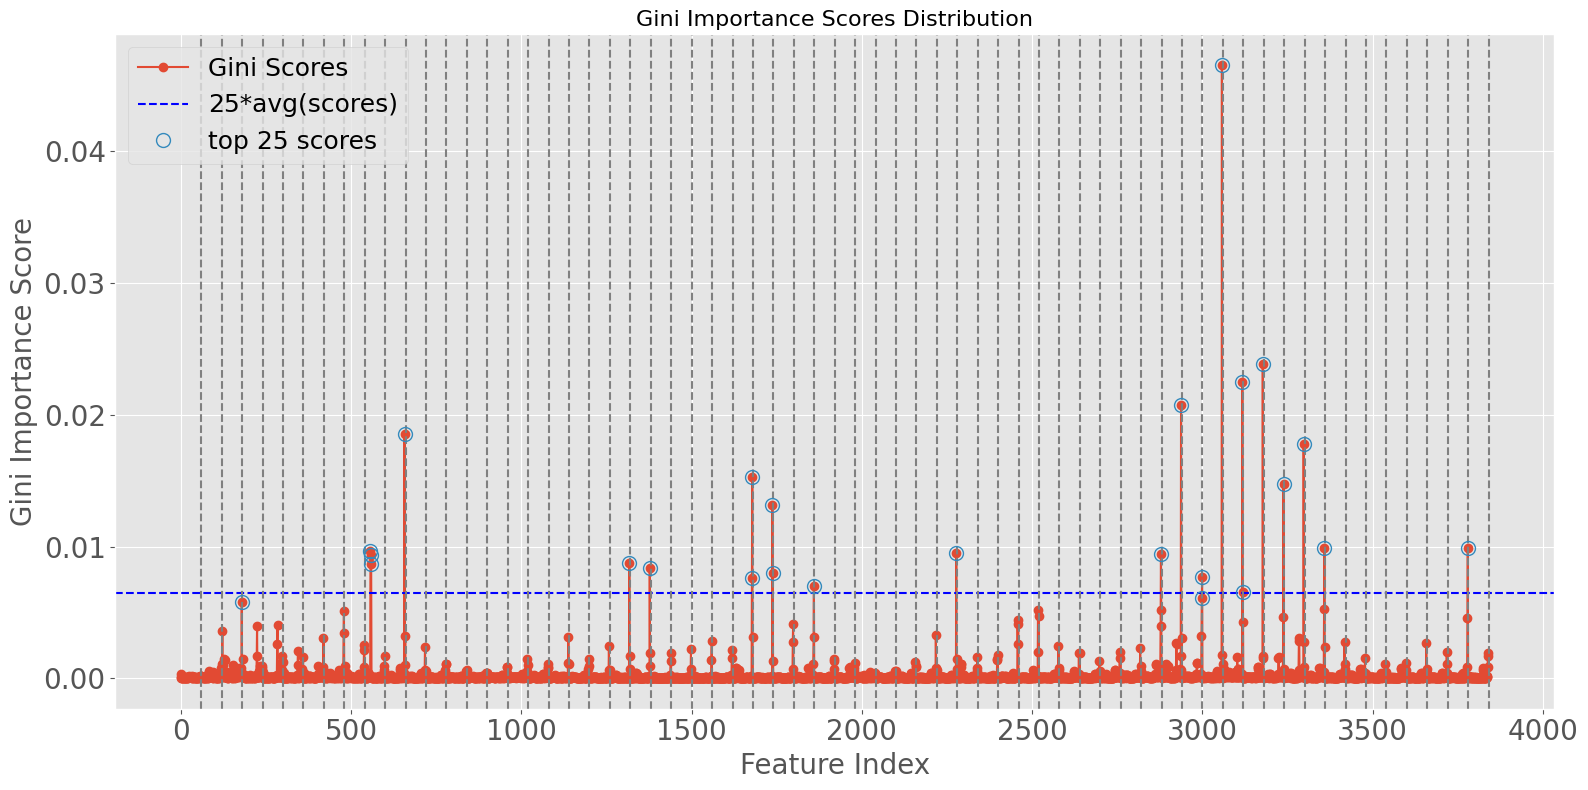

In [3]:
plt.figure(figsize=(16,8))
plt.plot(scores, "-o", label="Gini Scores")
plt.axhline(25*np.mean(scores), color="blue", linestyle='--', label="25*avg(scores)")
for i in range(64):
  plt.axvline(60*(i+1), color="gray", linestyle='--')
plt.plot(
    idx[:25],
    np.sort(scores)[::-1][:25],
    'o',
    markersize=10,
    markeredgewidth=1,
    markerfacecolor='none',
    label="top 25 scores"
)
plt.title("Gini Importance Scores Distribution", fontsize=16)
plt.xlabel("Feature Index", fontsize=20)
plt.ylabel("Gini Importance Score", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()

In [4]:
all_scores = []
for i in range(64):
  score = scores[(i)*60:(i+1)*60]
  all_scores.append(score)
all_scores = np.array(all_scores)

In [5]:
len(np.sum(all_scores, axis=0))

60

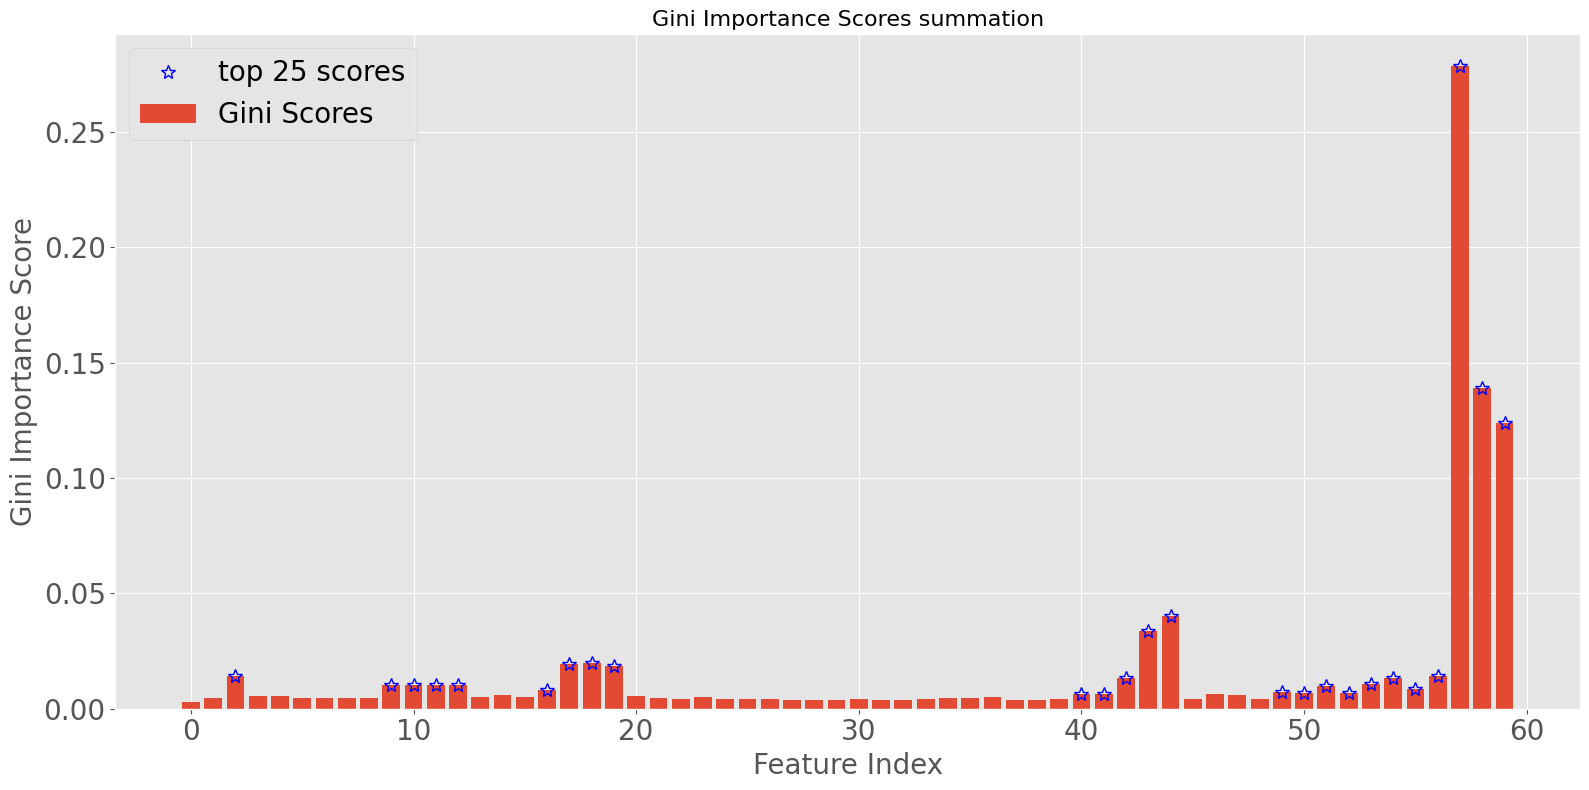

In [7]:
plt.figure(figsize=(16,8))

plt.bar(np.arange(60), np.sum(all_scores, axis=0), label="Gini Scores")

plt.plot(
    np.argsort(np.sum(all_scores, axis=0))[::-1][:25],
    np.sort(np.sum(all_scores, axis=0))[::-1][:25],
    '*',
    markersize=10,
    markeredgewidth=1,
    markerfacecolor='none',
    label="top 25 scores",
    color='blue'
)
plt.title("Gini Importance Scores summation", fontsize=16)
plt.xlabel("Feature Index", fontsize=20)
plt.ylabel("Gini Importance Score", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()

per sensor scores

In [8]:
import pandas as pd

# f_values= np.linspace(1000, 50000, 981)
f_values = np.array([43630, 44120, 42650, 45590,  6390, 44610, 23540, 45100,  6880,
       42160,  2960, 46080, 43140, 24030, 49510, 39220,  3940,  5410,
       38730, 37260,  3450, 25010, 20600, 20110,  5900, 41180,  4430,
        4920, 24520, 47060, 40200, 37750, 41670, 46570, 50000, 39710,
       38240, 36770, 48040, 48530,  7370, 18640, 49020,  2470, 47550,
       40690, 22070, 36280, 23050,  7860, 19620, 18150, 19130, 35300,
       21090, 28930, 21580, 25990,  8840, 11290,  8350,  9330,  1980,
       35790])
f_values = np.sort(f_values)
df = pd.DataFrame()
df["indices"] = np.arange(60)
for i, f in enumerate(f_values):
  df[f"scores_{int(f)}"] = scores[(i)*60:(i+1)*60]

In [9]:
df.describe()

,indices,scores_1980,scores_2470,scores_2960,scores_3450,scores_3940,scores_4430,scores_4920,scores_5410,scores_5900,...,scores_45590,scores_46080,scores_46570,scores_47060,scores_47550,scores_48040,scores_48530,scores_49020,scores_49510,scores_50000
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,...,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,29.500000,0.000088,0.000136,0.000456,0.000281,0.000292,0.000202,0.000191,0.000286,0.000209,...,0.000624,0.000431,0.000164,0.000170,0.000121,0.000144,0.000145,0.000142,0.000336,0.000161
std,17.464249,0.000048,0.000130,0.000884,0.000585,0.000660,0.000362,0.000413,0.000775,0.000437,...,0.002335,0.001439,0.000374,0.000227,0.000160,0.000208,0.000349,0.000290,0.001389,0.000346
min,0.000000,0.000038,0.000047,0.000055,0.000044,0.000039,0.000038,0.000043,0.000051,0.000042,...,0.000033,0.000033,0.000031,0.000036,0.000034,0.000034,0.000032,0.000032,0.000034,0.000032
25%,14.750000,0.000052,0.000064,0.000099,0.000073,0.000053,0.000058,0.000062,0.000070,0.000064,...,0.000073,0.000066,0.000054,0.000056,0.000051,0.000048,0.000051,0.000048,0.000054,0.000049
50%,29.500000,0.000073,0.000100,0.000164,0.000108,0.000083,0.000081,0.000081,0.000101,0.000084,...,0.000120,0.000102,0.000087,0.000096,0.000072,0.000063,0.000065,0.000072,0.000068,0.000061
75%,44.250000,0.000110,0.000135,0.000404,0.000166,0.000145,0.000125,0.000134,0.000190,0.000121,...,0.000354,0.000188,0.000117,0.000210,0.000117,0.000142,0.000100,0.000106,0.000100,0.000094
max,59.000000,0.000301,0.000757,0.005819,0.003990,0.004034,0.002072,0.003051,0.005119,0.002556,...,0.017768,0.009887,0.002750,0.001546,0.001122,0.001186,0.002663,0.002011,0.009911,0.001894


In [10]:
# select score columns
score_cols = [c for c in df.columns if c.startswith("scores_")]

# mean score per frequency (column-wise)
mean_scores = df[score_cols].mean(axis=0)

# sort from high to low
mean_scores_sorted = mean_scores.sort_values(ascending=False)

# mean_scores_sorted

In [11]:
best_frequencies = mean_scores_sorted.index.str.replace("scores_", "").astype(int)
# best_frequencies

In [12]:
# plt.plot(np.sort(best_frequencies), mean_scores_sorted, "o-")
test_df = pd.DataFrame()
test_df['freq'] = best_frequencies
test_df["mean"] = mean_scores_sorted.values
test_df = test_df.sort_values(by="freq")

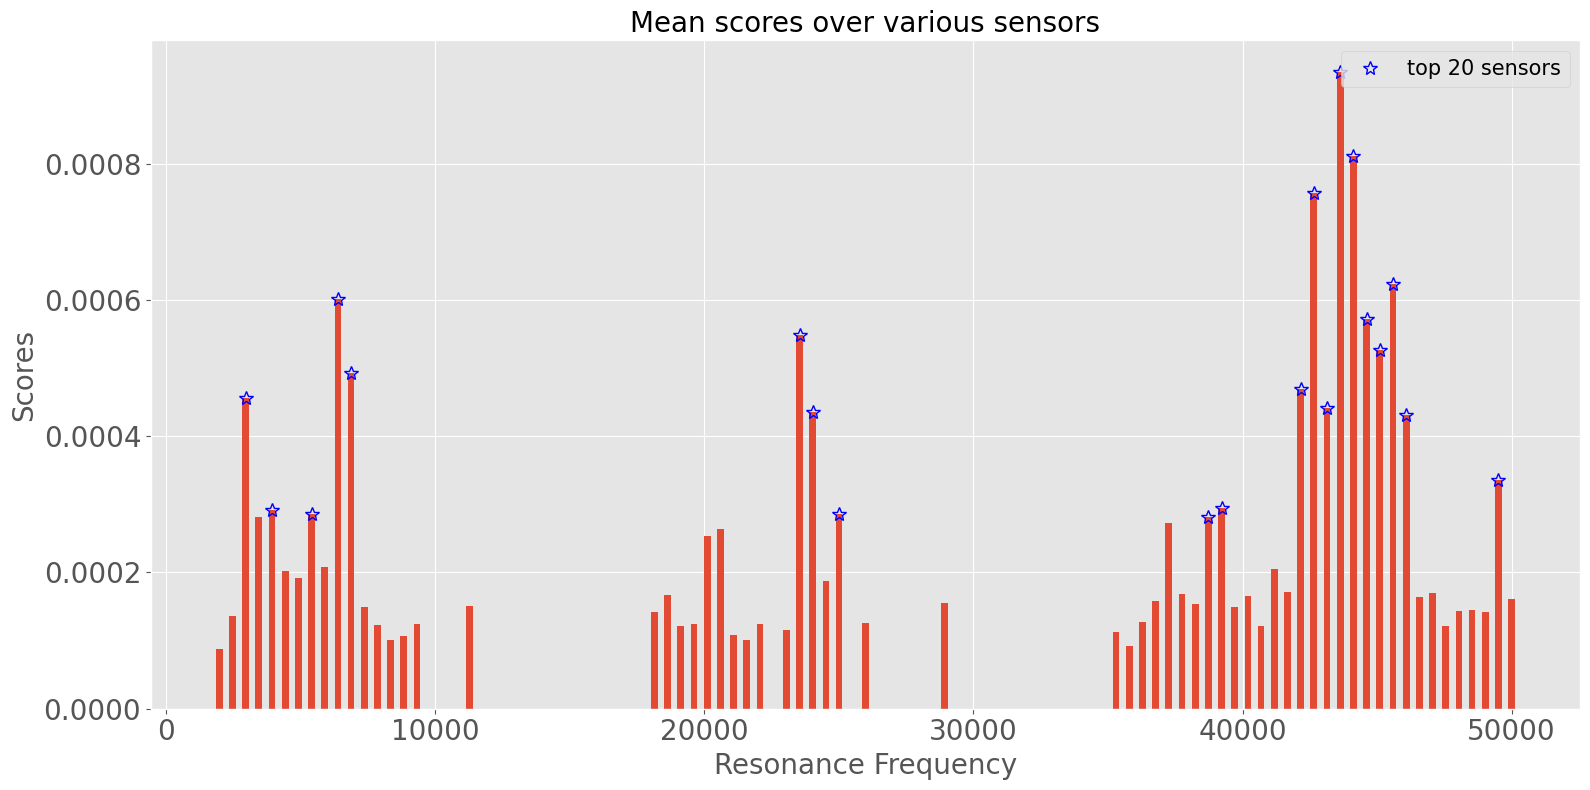

In [16]:
plt.figure(figsize=(16,8))
plt.bar(x=test_df['freq'], height=test_df['mean'], width=250)
plt.plot(
    test_df.sort_values(by="mean", ascending=False)["freq"][:20],
    test_df.sort_values(by="mean", ascending=False)["mean"][:20],
    '*',
    markersize=10,
    markeredgewidth=1,
    markerfacecolor='none',
    label="top 20 sensors",
    color='blue'
)
plt.xlabel("Resonance Frequency", fontsize=20)
plt.ylabel("Scores", fontsize=20)
plt.title("Mean scores over various sensors", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.legend(fontsize=15, loc="upper right")
plt.show()

In [18]:
np.sort(np.array(test_df.sort_values(by="mean", ascending=False)["freq"][:20]))

array([ 2960,  3940,  5410,  6390,  6880, 23540, 24030, 25010, 38730,
       39220, 42160, 42650, 43140, 43630, 44120, 44610, 45100, 45590,
       46080, 49510])